In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

project_path = '/content/drive/MyDrive/cnn_project'
os.makedirs(project_path, exist_ok=True)

IMPORT LIBRARIES

In [6]:
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Flatten, Rescaling, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

LOAD CIFAR-10 DATASET

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 173s 1us/step


DEFINE CLASS NAMES

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

LOAD MODELS

In [4]:
project_path = '/content/drive/MyDrive/cnn_project'

In [11]:
#CNN best model
model_cnn = tf.keras.models.load_model(f'{project_path}/models/cnn2_final.keras')

#MobileNet best model
model_mobilenet = tf.keras.models.load_model(f'{project_path}/models/mobilenet_cifar10.keras')

#EfficientNetB0 best model
model_effnet = tf.keras.models.load_model(f'{project_path}/models/efficientnetb0_cifar10.keras')

#DenseNet121 best model
model_densenet = tf.keras.models.load_model(f'{project_path}/models/densenet_final.keras')

CONFIGURATION

In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 10

ONE-HOT ENCODE LABELS

In [12]:
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [16]:
# Evaluate models

#CNN
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test_cat)
print(f"CNN Test Accuracy: {test_acc_cnn:.4f}")
print(f"CNN Test Loss: {test_loss_cnn:.4f}")
"""
#MobileNet
test_loss_mobilenet, test_acc_mobilenet = model_mobilenet.evaluate(X_test, y_test_cat)
print(f"MobileNet Test Accuracy: {test_acc_mobilenet:.4f}")
print(f"MobileNet Test Loss: {test_loss_mobilenet:.4f}")
"""
#EfficientNetB0
test_loss_effnet, test_acc_effnet = model_effnet.evaluate(X_test, y_test_cat)
print(f"EfficientNetB0 Test Accuracy: {test_acc_effnet:.4f}")
print(f"EfficientNetB0 Test Loss: {test_loss_effnet:.4f}")

#DenseNet121
test_loss_densenet, test_acc_densenet = model_densenet.evaluate(X_test, y_test_cat)
print(f"DenseNet121 Test Accuracy: {test_acc_densenet:.4f}")
print(f"DenseNet121 Test Loss: {test_loss_densenet:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1488 - loss: 1174.7996
CNN Test Accuracy: 0.1488
CNN Test Loss: 1174.7996
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9490 - loss: 0.2285
EfficientNetB0 Test Accuracy: 0.9490
EfficientNetB0 Test Loss: 0.2285
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.1169 - loss: 48.7623
DenseNet121 Test Accuracy: 0.1169
DenseNet121 Test Loss: 48.7623


In [18]:
# Predictions

#CNN
y_pred_probs_cnn = model_cnn.predict(X_test)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)
"""
#MobileNet
y_pred_probs_mobilenet = model_mobilenet.predict(X_test)
y_pred_mobilenet = np.argmax(y_pred_probs_mobilenet, axis=1)
"""
#EfficientNetB0
y_pred_probs_effnet = model_effnet.predict(X_test)
y_pred_effnet = np.argmax(y_pred_probs_effnet, axis=1)

#DenseNet121
y_pred_probs_densenet = model_densenet.predict(X_test)
y_pred_densenet = np.argmax(y_pred_probs_densenet, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 130ms/step


In [19]:
# Classification report

#CNN
report_cnn = classification_report(y_test, y_pred_cnn, target_names=class_names)
print(report_cnn)
"""
#MobileNet
report_mobilenet = classification_report(y_test, y_pred_mobilenet, target_names=class_names)
print(report_mobilenet)
"""
#EfficientNetB0
report_effnet = classification_report(y_test, y_pred_effnet, target_names=class_names)
print(report_effnet)

#DenseNet121
report_densenet = classification_report(y_test, y_pred_densenet, target_names=class_names)
print(report_densenet)

              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00      1000
  automobile       0.90      0.01      0.02      1000
        bird       0.00      0.00      0.00      1000
         cat       0.00      0.00      0.00      1000
        deer       1.00      0.00      0.01      1000
         dog       0.32      0.04      0.07      1000
        frog       0.00      0.00      0.00      1000
       horse       0.11      0.99      0.20      1000
        ship       0.00      0.00      0.00      1000
       truck       0.42      0.45      0.43      1000

    accuracy                           0.15     10000
   macro avg       0.27      0.15      0.07     10000
weighted avg       0.27      0.15      0.07     10000

              precision    recall  f1-score   support

    airplane       0.97      0.96      0.96      1000
  automobile       0.97      0.97      0.97      1000
        bird       0.97      0.93      0.95      1000
         cat       0.90 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

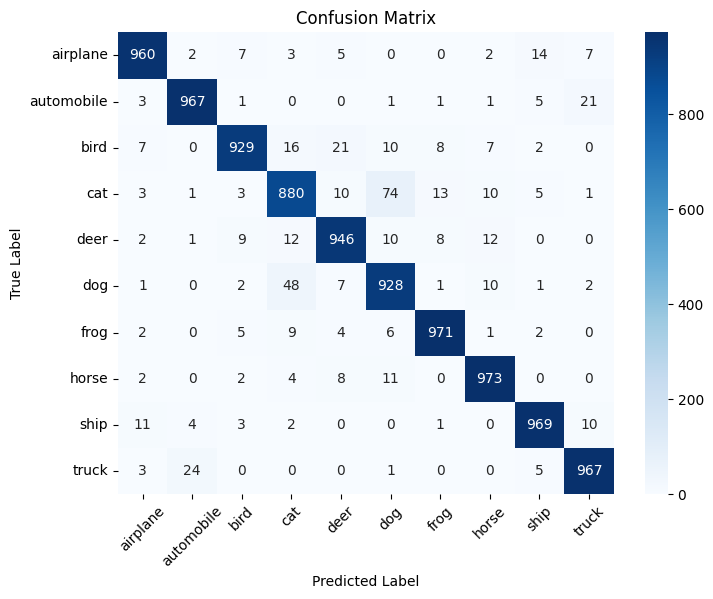

In [20]:
# Confusion matrix for EfficientNetB0 (best model)
cm = confusion_matrix(y_test, y_pred_effnet)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

CREATE DATASET FUNCTION

In [ ]:
def create_dataset(preprocess_function):

    train_dataset = tf.data.Dataset.from_tensor_slices(
        (X_train, y_train_cat)
    )

    test_dataset = tf.data.Dataset.from_tensor_slices(
        (X_test, y_test_cat)
    )

    def preprocess(image, label):

        image = tf.image.resize(
            image,
            (IMG_SIZE, IMG_SIZE)
        )

        image = preprocess_function(image)

        return image, label

    train_dataset = (
        train_dataset
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(10000)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    test_dataset = (
        test_dataset
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

    return train_dataset, test_dataset

BUILD MODEL FUNCTION

In [ ]:
def build_model(base_model):

    base_model.trainable = False

    model = Sequential([

        base_model,

        GlobalAveragePooling2D(),

        Dense(
            64,
            activation='relu'
        ),

        Dropout(0.2),

        Dense(
            10,
            activation='softmax'
        )

    ])

    model.compile(

        optimizer='adam',

        loss='categorical_crossentropy',

        metrics=['accuracy']

    )

    return model

TRAIN MOBILENETV2 (LAXMI)

TRAIN DENSENET121 (JAN)

TRAIN EFFICIENTNETB0 (BRUNO)

EVALUATE ALL MODELS

CREATE COMPARISON TABLE

In [ ]:
results = pd.DataFrame({

    'Model': [

        'MobileNetV2',
        'DenseNet121',
        'EfficientNetB0'
    ],

    'Accuracy': [

        mobilenet_acc,
        densenet_acc,
        efficientnet_acc
    ],

    'Loss': [

        mobilenet_loss,
        densenet_loss,
        efficientnet_loss
    ]
})

results

PLOT ACCURACY COMPARISON

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(

    results['Model'],

    results['Accuracy']

)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

PLOT LOSS COMPARISON

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(

    results['Model'],

    results['Loss']

)

plt.title("Model Loss Comparison")

plt.ylabel("Loss")

plt.show()

PLOT TRAINING CURVES

In [ ]:
plt.figure(figsize=(12,5))

# MobileNet
plt.plot(
    mobilenet_history.history['val_accuracy'],
    label='MobileNetV2'
)

# DenseNet
plt.plot(
    densenet_history.history['val_accuracy'],
    label='DenseNet121'
)

# EfficientNet
plt.plot(
    efficientnet_history.history['val_accuracy'],
    label='EfficientNetB0'
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.legend()

plt.show()

BEST MODEL

In [ ]:
best_model = results.loc[
    results['Accuracy'].idxmax()
]

print(best_model)

CLASSIFICATION REPORT (BEST MODEL)

In [ ]:
y_pred_probs = efficientnet_model.predict(
    efficientnet_test
)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

y_true = y_test.flatten()

print(

    classification_report(

        y_true,
        y_pred,

        target_names=class_names

    )

)

CONFUSION MATRIX

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("EfficientNetB0 Confusion Matrix")

plt.show()

FINAL COMPARISON SUMMARY

In [ ]:
print("\nFINAL MODEL COMPARISON\n")

print(results)

CONCLUSION

In [ ]:
print("""

Conclusion:

1. MobileNetV2:
   - Lightweight
   - Fastest training
   - Lowest resource usage

2. DenseNet121:
   - Better feature reuse
   - Strong accuracy
   - Higher computational cost

3. EfficientNetB0:
   - Best balance of efficiency and accuracy
   - Modern scaling approach
   - Best overall performer

""")